# Project: Employee Attrition Analyzer
**Name:** YOUR NAME  |  **Roll No:** YOUR ROLL NO  
**Course:** Machine Learning  |  **Lab 07 – Open Ended Lab**

**Goal:** Predict whether an employee will leave the company (Attrition = Yes/No) using the IBM HR Analytics dataset.  
**Models:** Logistic Regression, Decision Tree, Random Forest.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
SEED = 42  # fixed seed so results are repeatable

## 2. Dataset description

In [2]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Rows, columns:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()

Rows, columns: (1470, 35)
Missing values: 0
Duplicate rows: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Column types and basic statistics
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [4]:
# Check the target column (Attrition)
print(df["Attrition"].value_counts())
print((df["Attrition"].value_counts(normalize=True) * 100).round(1))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


**Dataset summary**
- 1,470 employees and 35 columns, with no missing values.
- Target: `Attrition` (Yes = left, No = stayed).
- Only about 16% of employees left, so the data is **imbalanced**. Accuracy alone can be misleading, so we also use precision, recall and F1.

## 3. Data visualization (EDA)

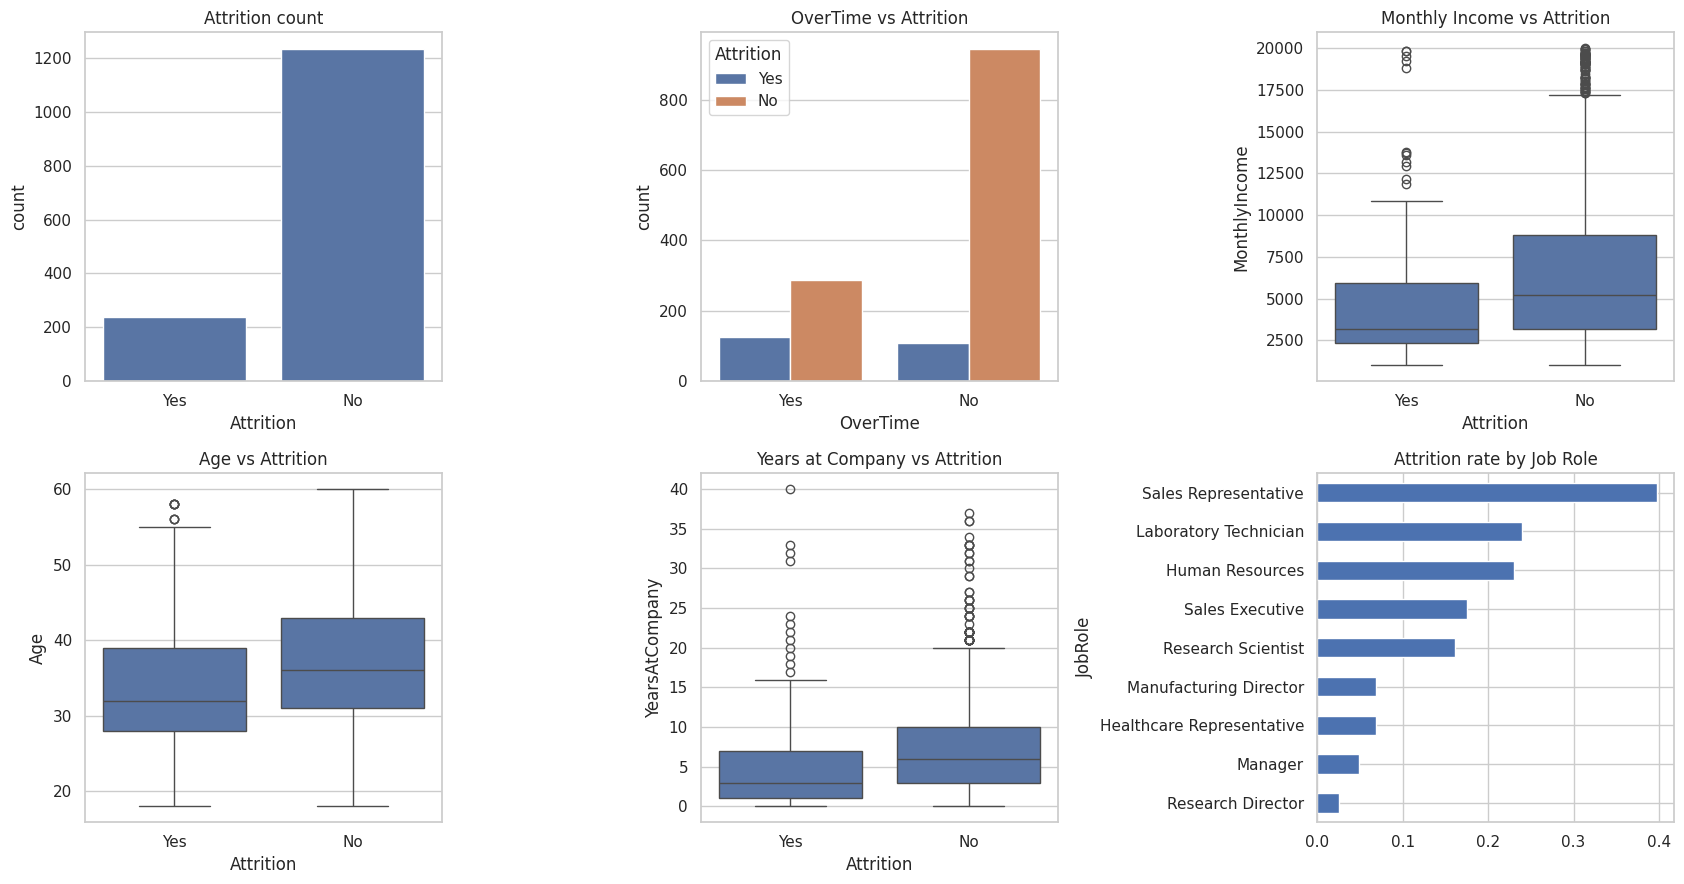

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))

sns.countplot(x="Attrition", data=df, ax=ax[0, 0])                    # class balance
ax[0, 0].set_title("Attrition count")

sns.countplot(x="OverTime", hue="Attrition", data=df, ax=ax[0, 1])    # overtime effect
ax[0, 1].set_title("OverTime vs Attrition")

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, ax=ax[0, 2])   # salary effect
ax[0, 2].set_title("Monthly Income vs Attrition")

sns.boxplot(x="Attrition", y="Age", data=df, ax=ax[1, 0])             # age effect
ax[1, 0].set_title("Age vs Attrition")

sns.boxplot(x="Attrition", y="YearsAtCompany", data=df, ax=ax[1, 1])  # experience effect
ax[1, 1].set_title("Years at Company vs Attrition")

# Attrition rate for each job role
rate = df.groupby("JobRole")["Attrition"].apply(lambda s: (s == "Yes").mean()).sort_values()
rate.plot(kind="barh", ax=ax[1, 2], title="Attrition rate by Job Role")

plt.tight_layout()
plt.show()

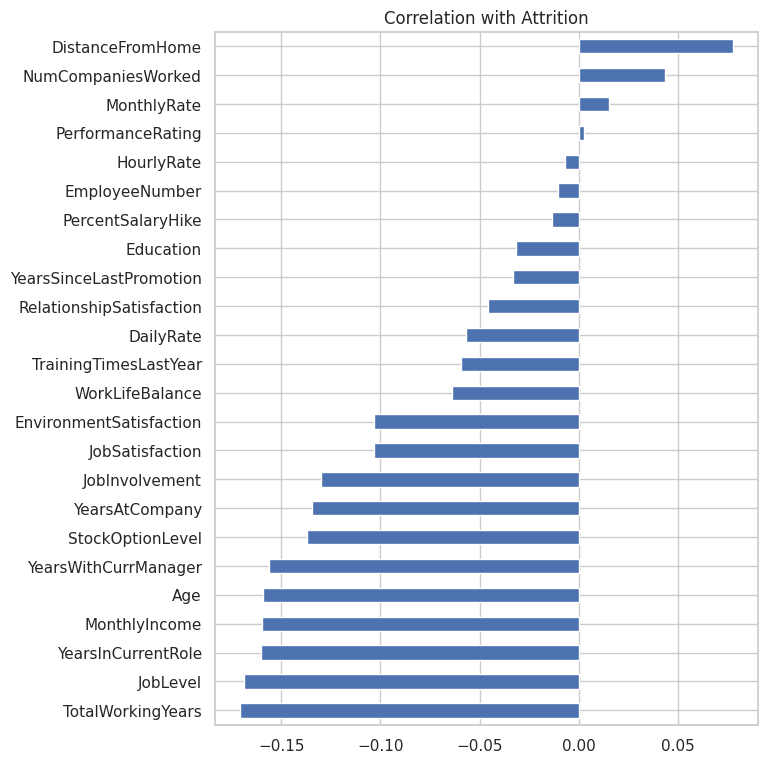

In [6]:
# Correlation of numeric features with Attrition
temp = df.copy()
temp["Attrition"] = (temp["Attrition"] == "Yes").astype(int)
corr = temp.select_dtypes("number").corr()["Attrition"].drop(["Attrition", "EmployeeCount", "StandardHours"])
corr.sort_values().plot(kind="barh", figsize=(7, 9), title="Correlation with Attrition")
plt.show()

## 4. Preprocessing
1. Drop useless columns: `EmployeeCount`, `StandardHours`, `Over18` (same value for everyone) and `EmployeeNumber` (just an ID).
2. Convert the target to numbers: Yes = 1, No = 0.
3. Encode text columns with One-Hot Encoding.
4. Scale numeric columns with StandardScaler.
5. Split into 80% train and 20% test (stratified, to keep the 16% ratio).

In [7]:
# 1. Remove columns that give no information
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

# 2. Target: Yes -> 1, No -> 0
y = (df["Attrition"] == "Yes").astype(int)
X = df.drop(columns="Attrition")

# Separate numeric and text columns
num_cols = X.select_dtypes("number").columns
cat_cols = X.select_dtypes("object").columns
print("Numeric columns:", len(num_cols), "| Text columns:", len(cat_cols))

# 3 and 4. Scale numbers, one-hot encode text
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Numeric columns: 23 | Text columns: 7
Train: (1176, 30) | Test: (294, 30)


/tmp/ipykernel_123/3010761643.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes("object").columns


## 5. Models and how they are integrated
Each model is put inside a **Pipeline** together with the preprocessing step. This way the same cleaning is applied to train and test data, and the test data is never used for fitting the scaler or encoder.

`class_weight="balanced"` makes the models give more importance to the rare "Yes" class.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=3,
                                            class_weight="balanced", random_state=SEED),
}

pipelines = {}   # trained models
results = []     # metrics table

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)            # train
    pred = pipe.predict(X_test)           # predict on unseen data
    pipelines[name] = pipe

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).round(3)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.752,0.349,0.638,0.451
1,Decision Tree,0.786,0.379,0.532,0.442
2,Random Forest,0.837,0.484,0.319,0.385


## 6. Model evaluation

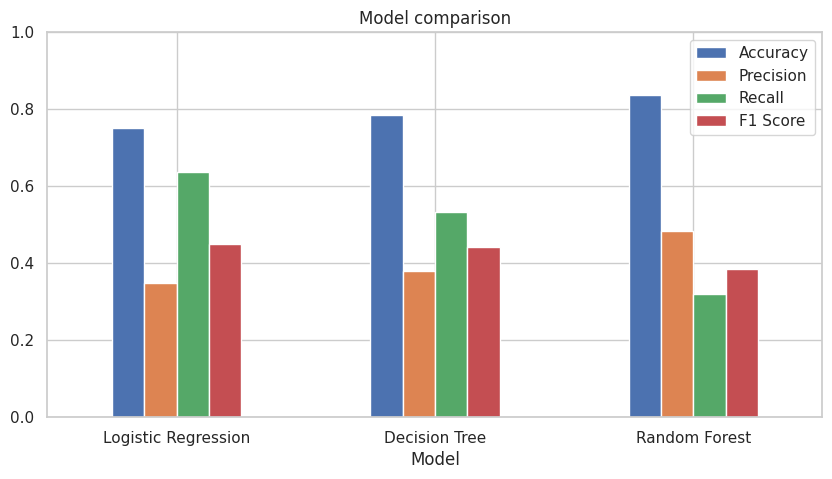

In [9]:
# Compare models with a bar chart
results_df.set_index("Model").plot(kind="bar", figsize=(10, 5), rot=0, title="Model comparison")
plt.ylim(0, 1)
plt.show()

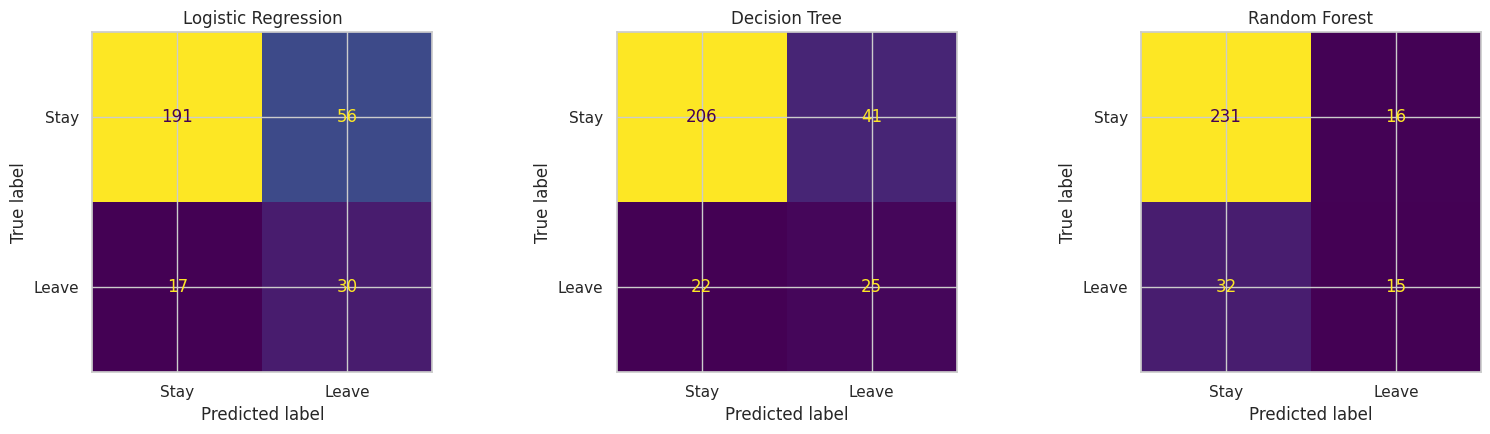

In [10]:
# Confusion matrix for each model
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, (name, pipe) in enumerate(pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Leave"]).plot(ax=ax[i], colorbar=False)
    ax[i].set_title(name)
plt.tight_layout()
plt.show()

In [11]:
# Detailed report for each model
for name, pipe in pipelines.items():
    print("=====", name, "=====")
    print(classification_report(y_test, pipe.predict(X_test), target_names=["Stay", "Leave"]))

===== Logistic Regression =====
              precision    recall  f1-score   support

        Stay       0.92      0.77      0.84       247
       Leave       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

===== Decision Tree =====
              precision    recall  f1-score   support

        Stay       0.90      0.83      0.87       247
       Leave       0.38      0.53      0.44        47

    accuracy                           0.79       294
   macro avg       0.64      0.68      0.65       294
weighted avg       0.82      0.79      0.80       294

===== Random Forest =====
              precision    recall  f1-score   support

        Stay       0.88      0.94      0.91       247
       Leave       0.48      0.32      0.38        47

    accuracy                           0.84       294
   macro avg       0.68      0.63      0.65 

## 7. Feature importance

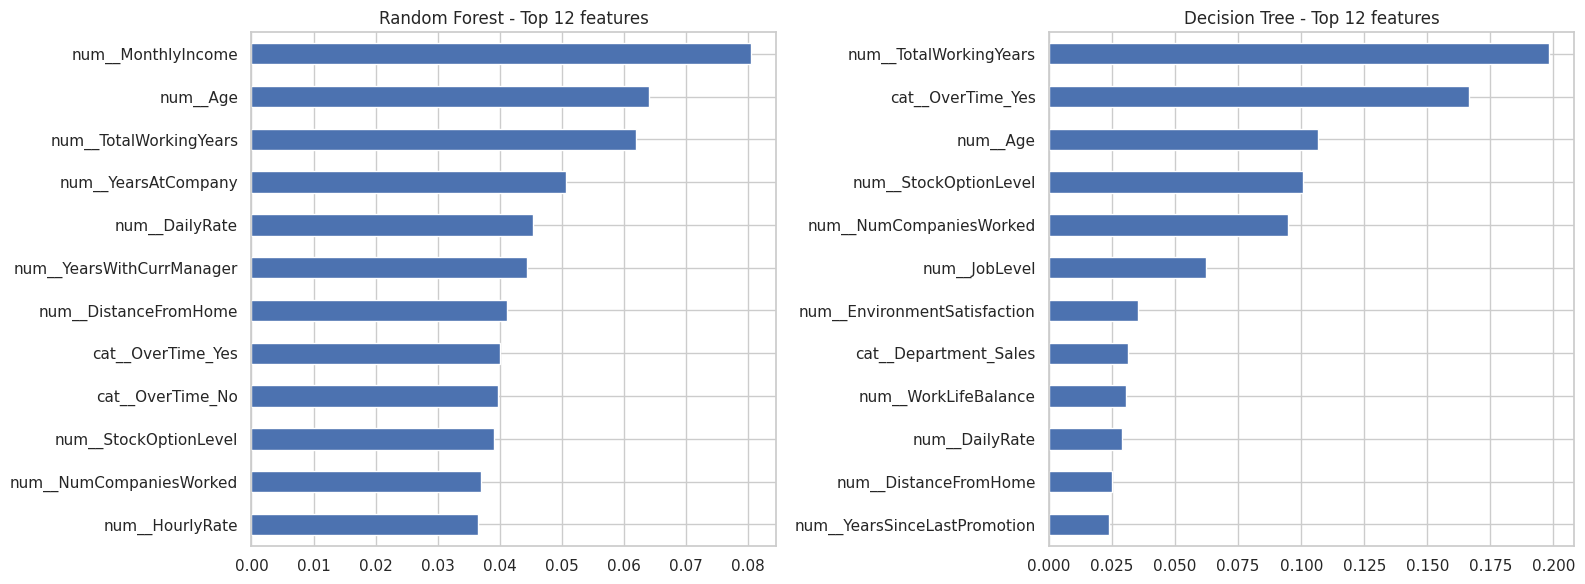

In [12]:
# Get feature names after encoding
feature_names = pipelines["Random Forest"].named_steps["prep"].get_feature_names_out()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest importance
rf = pipelines["Random Forest"].named_steps["model"]
pd.Series(rf.feature_importances_, index=feature_names).nlargest(12).iloc[::-1] \
    .plot(kind="barh", ax=ax[0], title="Random Forest - Top 12 features")

# Decision Tree importance
dt = pipelines["Decision Tree"].named_steps["model"]
pd.Series(dt.feature_importances_, index=feature_names).nlargest(12).iloc[::-1] \
    .plot(kind="barh", ax=ax[1], title="Decision Tree - Top 12 features")

plt.tight_layout()
plt.show()

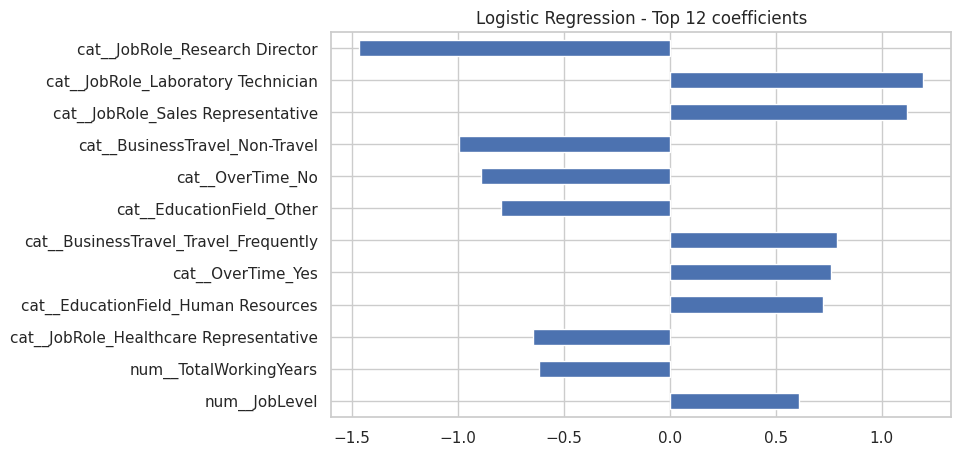

In [13]:
# Logistic Regression: coefficients show the direction of the effect
# (positive = more likely to leave, negative = more likely to stay)
lr = pipelines["Logistic Regression"].named_steps["model"]
coef = pd.Series(lr.coef_[0], index=feature_names)
top = coef.reindex(coef.abs().nlargest(12).index)
top.iloc[::-1].plot(kind="barh", figsize=(8, 5), title="Logistic Regression - Top 12 coefficients")
plt.show()

## 8. Conclusion
- **Imbalanced data:** only about 16% of employees left, so accuracy is misleading. Random Forest has the highest accuracy (0.84) but finds the fewest leavers (recall 0.32).
- **Best for finding leavers:** Logistic Regression has the highest recall (0.64) and F1 (0.45). Decision Tree is close behind (recall 0.53, F1 0.44).
- **Trade-off:** higher recall means more false alarms (lower precision). If the company wants to catch as many leavers as possible, Logistic Regression is the better choice.
- **Important features:** MonthlyIncome, Age, TotalWorkingYears and YearsAtCompany (Random Forest); TotalWorkingYears, OverTime, Age and StockOptionLevel (Decision Tree). Employees who work overtime, are younger and are earlier in their careers are more likely to leave.
- **Limitations:** small dataset, and the scores are moderate (F1 below 0.5).
- **Future work:** hyperparameter tuning (GridSearchCV), SMOTE, and gradient boosting.
